<a href="https://colab.research.google.com/github/BCanavan/Belinda_INFO4670_Fall2024/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [1]:
# Import libraries and load data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the dataset
dataset = pd.read_csv('car_purchase_data.csv')

# Preview the dataset
print(dataset.head())
print(dataset.info())

    User ID  Gender  Age  Salary  Purchased
0  15624510    Male   19   19000          0
1  15810944    Male   35   20000          0
2  15668575  Female   26   43000          0
3  15603246  Female   27   57000          0
4  15804002    Male   19   76000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   User ID    400 non-null    int64 
 1   Gender     400 non-null    object
 2   Age        400 non-null    int64 
 3   Salary     400 non-null    int64 
 4   Purchased  400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


### Step 2: Split features and target

In [4]:
# Split features and target
# Selecting AGE and SALARY as the input features because we are predicting
# car puchases using these two variables. Target = Purchased (yes/no).

x = dataset[['Age', 'Salary']].values
y = dataset['Purchased'].values

print("Features (x):")
print(x[:5])

print("\nTarget (y):")
print(y[:5])

Features (x):
[[   19 19000]
 [   35 20000]
 [   26 43000]
 [   27 57000]
 [   19 76000]]

Target (y):
[0 0 0 0 0]


### Step 3: Train/Test Split

In [6]:
# Train/Test Split. Divide the data so the model can be tested fairly
# 75% training data, 25% testing data
# We split the training and testing sets so that the model can learn from
# a portion of data and be evaluated on a portion of 'unseen' data.
x_train, x_test, y_train, y_test = train_test_split(
    x, y , test_size=0.25, random_state=0
)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)



x_train shape: (300, 2)
x_test shape: (100, 2)
y_train shape: (300,)
y_test shape: (100,)


### Step 4: Feature Scaling

In [7]:
# Feature Scaling
# Standardize values

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

print("Scaled x_train (first 5 rows):")
print(x_train[:5])

print("\nScaled x_test (First 5 rows):")
print(x_test[:5])

Scaled x_train (first 5 rows):
[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]]

Scaled x_test (First 5 rows):
[[-0.80480212  0.50496393]
 [-0.01254409 -0.5677824 ]
 [-0.30964085  0.1570462 ]
 [-0.80480212  0.27301877]
 [-0.30964085 -0.5677824 ]]


### Step 5: Train Logistic Regression Model

In [8]:
# Train the Logistic Regression Model

classifier = LogisticRegression(random_state=0)
classifier.fit(x_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Step 6: Predict and Evaluate

In [9]:
# Predict and Evaluate

y_pred = classifier.predict(x_test)

print(y_pred[:10])

print("\nActual values (first 10):")
print(y_test[:10])

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

[0 0 0 0 0 0 0 1 0 1]

Actual values (first 10):
[0 0 0 0 0 0 0 1 0 0]

Confusion Matrix:
[[65  3]
 [ 8 24]]

Accuracy: 0.89
Accuracy (%): 89.0


### Step 7: Visualization of Decision Regions

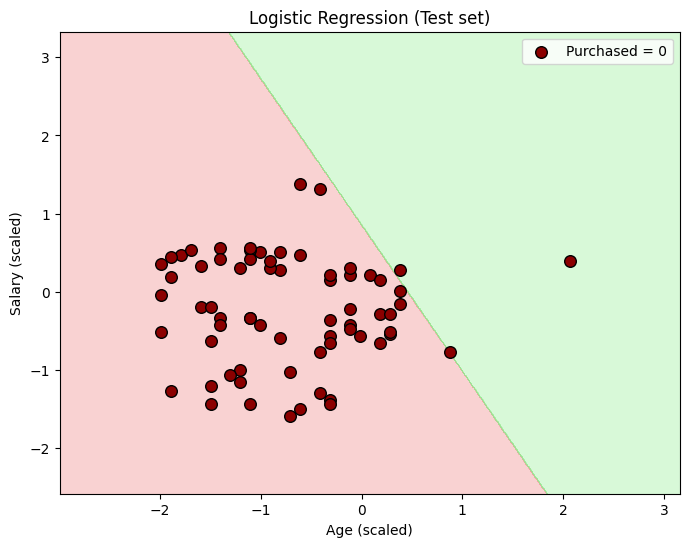

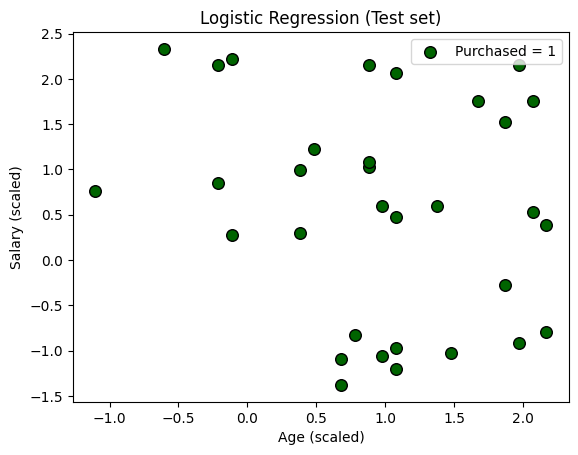

In [12]:
# Visualization of Decision Regions

from matplotlib.colors import ListedColormap
import numpy as np

# Create a mesh grid based on the test set
x_set, y_set = x_test, y_test
x1, x2 = np.meshgrid(
    np.arange(start = x_set[:, 0].min() - 1, stop = x_set[:, 0].max() + 1, step = 0.01),
    np.arange(start = x_set[:,1].min() - 1, stop = x_set[:, 1].max() + 1, step = 0.01)
)

# Predict decision regions
Z = classifier.predict(np.array([x1.ravel(), x2.ravel()]).T)
Z = Z.reshape(x1.shape)

# Plot decision boundary with lighter background colors
plt.figure(figsize=(8, 6))
plt.contourf(
    x1, x2, Z,
    alpha=0.35,
    cmap=ListedColormap(('lightcoral', 'lightgreen'))
)

# Plot the test points using darker colors and black edges
for i, j in enumerate(np.unique(y_set)):
  plt.scatter(
      x_set[y_set == j, 0],
      x_set[y_set == j, 1],
      color=['darkred', 'darkgreen'][i],
      edgecolor='black',
      s=70,
      label=f'Purchased = {j}'
  )

  plt.title('Logistic Regression (Test set)')
  plt.xlabel('Age (scaled)')
  plt.ylabel('Salary (scaled)')
  plt.legend()
  plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. Logistic regression predicts the probability that a data point belongs to class 1 (purchased). Although the output is a probability between 0 and 1, it can be used for classification by applying a threshold (such as 0.5). If the predicted probability is 0.5 or greater, the model classifies that item (in this case, a customer) as 1, showing that they will likely purchase. If it is less than 0.5, the model classifies the item in another class (will not purchase).

2. Customers who are older and/or have higher saleries are more likely to purchase a car. Age and salary influence the likelihood of buying a car in this dataset.

3. There are several factors that could lower the accuracy. Using only Age and Salary may not capture all of the reasons why a customer purchases a car. There also may be overalp between the two classes, making it difficult to separate these concepts entirely. Outliers also occur which can affect the decision boundary.

4. The accuracy of this model could be improved by adding more relevant features such as gender, credit score, car ownership history, family size, marital status, or location. Additional preprocessing steps could include handling outliers, or checking for class imblance.